# Règles d'association — Analyse du Bread Basket

## Contexte
Une boulangerie écossaise propose plusieurs produits : **Coffee**, **Bread**,
**Tea**, **Cake**, **Pastry**, entre autres.

Chaque jour, des centaines de clients passent en caisse. Le gérant observe que
certains produits semblent toujours achetés ensemble — mais il n'a pas de moyens de savoir les combinaisons fréquentes pour améliorer ses ventes.

L'objectif de ce TP est de **découvrir automatiquement ces associations** à partir
de l'historique des transactions, afin de répondre à des questions concrètes :

- Quel produit proposer en promotion groupée avec le café ?
- Comment organiser l'espace de vente pour maximiser les ventes croisées ?

## Dataset
- **Source** : Kaggle — The Bread Basket  
- **Volume** : ~21 000 transactions  
- **Colonnes** : `Transaction`, `Item`, `date_time`, `period_day`, `weekday_month`

In [1]:
!pip install mlxtend #bibliothèque

## Preparer l'environnement

In [2]:
#importer les packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')
warnings.filterwarnings('ignore', category=FutureWarning, module='matplotlib')

In [3]:
#configuration de pandas

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3}'.format)

## Étape 1 — Chargement et exploration

- Combien de transactions ?
- Combien de produits distincts ?
- Y a-t-il des valeurs manquantes ?
- Quelle est la distribution des produits ?

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/EPL/Data Mining/bread basket.csv')
print("Dimensions :", df.shape)
print("Colonnes :", df.columns.tolist())
print('Quelques lignes \n\n', df.sample(10))

Dimensions : (20507, 5)
Colonnes : ['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend']
Quelques lignes 

        Transaction        Item         date_time period_day weekday_weekend
5414          2681       Bread  05-12-2016 16:23  afternoon         weekday
10181         5105       Bread  21-01-2017 15:53  afternoon         weekend
2745          1323  Farm House  14-11-2016 13:45  afternoon         weekday
16193         7713        Cake  06-03-2017 15:15  afternoon         weekday
19377         9173      Coffee  01-04-2017 10:22    morning         weekend
16191         7713         Tea  06-03-2017 15:15  afternoon         weekday
19678         9300     Cookies  03-04-2017 12:03  afternoon         weekday
9210          4645       Toast  14-01-2017 09:07    morning         weekend
3650          1773       Bread  20-11-2016 13:48  afternoon         weekend
5223          2594   Alfajores  04-12-2016 12:04  afternoon         weekend


In [6]:
print("Nombre de lignes:", len(df))
print("Nombre de Transactions unique: ", df['Transaction'].nunique())
print("Nombre de Produits unique: ", df['Item'].nunique())
print("Valeurs manquantes . \n", df.isna().sum())

Nombre de lignes: 20507
Nombre de Transactions unique:  9465
Nombre de Produits unique:  94
Valeurs manquantes . 
 Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64


/tmp/ipykernel_2596/72874474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y= top_products.index, palette='Blues_d')


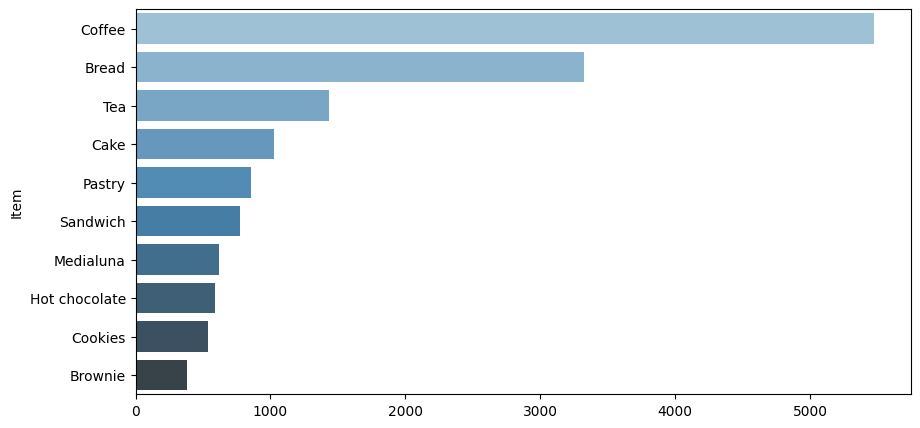

In [7]:
#produits les plus fréquents dans les commandes

top_products = df['Item'].value_counts().head(10)
top_products
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y= top_products.index, palette='Blues_d')
plt.show()

## Étape 2 — Nettoyage

Traiter les potentiels problèmes:
1. **Valeurs manquantes** — lignes sans produit identifié
2. **Casse et espaces** — "coffee", "Coffee", " Coffee" doivent être le même produit
3. **Produits rares** — produits apparaissant moins de 10 fois, non exploitables

In [8]:
#normalisation
print(df['Item'].isna().sum())
df.dropna(subset='Item', inplace=True)
df['Item'] = df['Item'].str.strip().str.title()

#verification
print("Produits distincts :", df['Item'].nunique())

0
Produits distincts : 94


In [9]:
#frquence des produits
freq_prod = df['Item'].value_counts()

#lister les produits rares
scarce_prod = freq_prod[freq_prod < 10].index
print("Produits rares :", scarce_prod.tolist())

#supprimer les produits rares
df = df[~df['Item'].isin(scarce_prod)]

#Afficher les données restantes
print("Produits restants :", df['Item'].nunique())
print("Transactions restantes : ", df['Transaction'].nunique())

Produits rares : ['Gingerbread Syrup', 'Drinking Chocolate Spoons', 'Nomad Bag', 'Muesli', 'Argentina Night', 'Coffee Granules', 'Victorian Sponge', 'Empanadas', 'Lemon And Coconut', 'Basket', 'Pintxos', 'Half Slice Monster', 'Crepes', 'Honey', 'Panatone', 'Mortimer', 'Bare Popcorn', 'Bread Pudding', 'Raspberry Shortbread Sandwich', 'Caramel Bites', 'Brioche And Salami', 'Cherry Me Dried Fruit', 'Siblings', 'Fairy Doors', 'Chimichurri Oil', 'Bowl Nic Pitt', 'Spread', 'Hack The Stack', 'Chicken Sand', 'Polenta', 'Bacon', 'Adjustment', 'The Bart', 'Olum & Polenta', 'Gift Voucher', 'Raw Bars']
Produits restants : 58
Transactions restantes :  9434


## Étape 3 — Transformation en matrice binaire

L'algorithme Apriori n'accepte pas le format ligne-par-produit.
Il faut transformer le dataset en **matrice binaire** où :
- Chaque **ligne** représente une transaction
- Chaque **colonne** représente un produit
- La valeur est **1** si le produit est dans la transaction, **0** sinon

Exemple :

| Transaction | Coffee | Bread | Tea | Cake |
|-------------|--------|-------|-----|------|
| 1           | 1      | 1     | 0   | 0    |
| 2           | 0      | 0     | 1   | 1    |
| 3           | 1      | 0     | 0   | 1    |

In [10]:
# Grouper les transactions
basket = df.groupby('Transaction')['Item'].apply(list).reset_index()

# Encoder en matrice binaire (bool pour éviter le warning mlxtend)
te = TransactionEncoder()
te_array = te.fit_transform(basket['Item'])

df_mat = pd.DataFrame(te_array, columns=te.columns_)  # bool par défaut

print("Dimensions de la matrice :", df_mat.shape)
df_mat.head()

Dimensions de la matrice : (9434, 58)


,Afternoon With The Baker,Alfajores,Art Tray,Baguette,Bakewell,Bread,Brownie,Cake,Chicken Stew,Chocolates,Christmas Common,Coffee,Coke,Cookies,Crisps,Duck Egg,Dulce De Leche,Eggs,Ella'S Kitchen Pouches,Extra Salami Or Feta,Farm House,Focaccia,Frittata,Fudge,Granola,Hearty & Seasonal,Hot Chocolate,Jam,Jammie Dodgers,Juice,Keeping It Local,Kids Biscuit,Medialuna,Mighty Protein,Mineral Water,Muffin,My-5 Fruit Shoot,Pastry,Pick And Mix Bowls,Postcard,Salad,Sandwich,Scandinavian,Scone,Smoothies,Soup,Spanish Brunch,Tacos/Fajita,Tartine,Tea,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine'S Card,Vegan Feast,Vegan Mincepie
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Étape 4 — Algorithme Apriori

L'algorithme Apriori est une méthode classique d'exploration de données (data mining) utilisée pour découvrir des relations cachées entre des variables dans de grands ensembles de données. Il s'agit d'un algorithme d'apprentissage automatique non supervisé qui permet d'extraire des règles d'association sous la forme « si... alors..

L'algorithme utilise Support comme metrique principale pour calculer la fréquences des itemsets :

- Support : Fréquence d'apparition d'un itemset (combinaison d'articles) dans l'ensemble des transactions.

$$support(A) = \frac{\text{nombre de transactions contenant A}}{\text{nombre total de transactions}}$$

Un support de 0.01 signifie que l'itemset apparaît dans
au moins 1% des transactions.


L'algorithme Apriori recherche les **itemsets fréquents** —
c'est-à-dire les combinaisons de produits qui apparaissent
dans un minimum de transactions.

In [11]:
frequent_itemsets = apriori(df_mat, min_support=0.01, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.0365,(Alfajores)
1,0.0161,(Baguette)
2,0.328,(Bread)
3,0.0402,(Brownie)
4,0.104,(Cake)
...,...,...
56,0.0237,"(Toast, Coffee)"
57,0.0144,"(Tea, Sandwich)"
58,0.0101,"(Coffee, Bread, Cake)"
59,0.0112,"(Pastry, Coffee, Bread)"


## Génération et interprétation des règles

- Confidence (Confiance) : Probabilité qu'un article B soit acheté sachant que l'article A est acheté.

$$ Confiance(A → B) = \frac{Support({A,B})}{Support({A})}$$

- Lift : Mesure si la règle est utile ou juste une coïncidence. Un lift > 1 indique une association forte.

$$ Lift(A → B) = \frac{Confiance({A,B})}{Support({B})}$$

In [12]:
# Générer les règles d'association à partir des itemsets fréquents
# metric='lift' : on filtre d'abord par lift > 1 (associations positives)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

# Garder uniquement les colonnes utiles et trier par lift décroissant
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"{len(rules)} règles générées")
rules.head(10)

42 règles générées


,antecedents,consequents,support,confidence,lift
0,"(Tea, Coffee)",(Cake),0.0101,0.201,1.93
1,(Cake),"(Tea, Coffee)",0.0101,0.0966,1.93
2,(Cake),(Hot Chocolate),0.0114,0.11,1.88
3,(Hot Chocolate),(Cake),0.0114,0.196,1.88
4,(Cake),(Tea),0.0238,0.229,1.6
5,(Tea),(Cake),0.0238,0.167,1.6
6,(Coffee),(Toast),0.0237,0.0495,1.47
7,(Toast),(Coffee),0.0237,0.704,1.47
8,"(Coffee, Bread)",(Pastry),0.0112,0.124,1.44
9,(Pastry),"(Coffee, Bread)",0.0112,0.13,1.44


## Visualisation

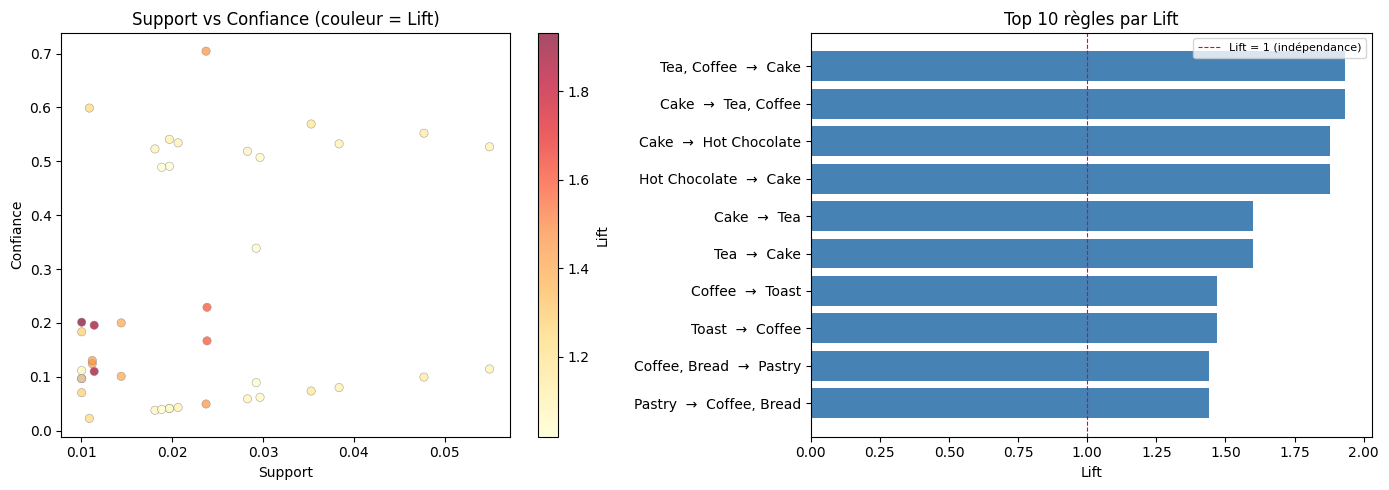

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique 1 : Support vs Confiance, coloré par Lift ───────────────────────
sc = axes[0].scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='grey',
    linewidths=0.4
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confiance')
axes[0].set_title('Support vs Confiance (couleur = Lift)')

# ── Graphique 2 : Top 10 règles par Lift ──────────────────────────────────────
top10 = rules.head(10).copy()
top10['règle'] = (
    top10['antecedents'].apply(lambda x: ', '.join(list(x)))
    + '  →  '
    + top10['consequents'].apply(lambda x: ', '.join(list(x)))
)

axes[1].barh(top10['règle'][::-1], top10['lift'][::-1], color='steelblue')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 règles par Lift')
axes[1].axvline(x=1, color='red', linestyle='--', linewidth=0.8, label='Lift = 1 (indépendance)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()